# Introductory machine learning for econometrics: Exploring the Mincer equation

**Purpose:** This notebook provides an in-depth introduction to machine learning (ML) algorithms from an econometric perspective. We'll explore how ML methods relate to and extend traditional econometric approaches, with a special focus on prediction, key modeling methods, and model interpretability.

**Audience:** This notebook is designed for students and practitioners with a background in econometrics who are new to machine learning.

## Imports and Setup

First, we'll import the necessary Python libraries. This includes standard data science libraries like `pandas` and `numpy`, visualization tools like `matplotlib` and `seaborn`, and the core machine learning library `scikit-learn`.

We also import specialized libraries: `shap` for advanced model interpretability and `econml` for causal inference. These are not pre-installed in Google Colab, so we must install them first using `pip`.

In [ ]:
# This command installs the specialized libraries required for this notebook.
# It's important to run this cell first in a new Colab environment.
!pip install shap econml ipywidgets stargazer -q

# Core data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import plotly.express as px
from stargazer.stargazer import Stargazer
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, roc_auc_score, roc_curve

# Libraries for advanced interpretation and causal inference
import shap
from econml.dml import CausalForestDML

# Libraries for interactive widgets
from ipywidgets import interact, FloatSlider

# Set a random seed for reproducibility. This ensures that anyone running this code
# will get the exact same results.
np.random.seed(42)

# Configure visualization settings for prettier plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print('Setup Complete.')

Setup Complete.


## Data Generation: Simulating an Economic Reality

To properly evaluate our models, we will simulate data from a known **Data Generating Process (DGP)**. This is a powerful pedagogical tool because it allows us to compare our model estimates to the "true" underlying parameters that we define.

The function below creates a dataset based on a **Mincer-style wage equation**, a staple in labor economics. Crucially, we include an unobserved confounding variable, `ability`, which is correlated with both `education` (our treatment variable) and `log_wage` (our outcome). This will allow us to explore the classic problem of **omitted variable bias** later on.

In [ ]:
def generate_economic_data(n_samples=1000, random_state=42):
    """
    Generates synthetic data based on a Mincer-style wage equation.
    """
    np.random.seed(random_state)

    # Independent variables
    education = np.random.normal(12, 3, n_samples)
    experience = np.random.uniform(0, 40, n_samples)
    experience_squared = experience ** 2
    # Unobserved ability is correlated with education
    ability = 0.3 * education + np.random.normal(0, 1, n_samples)
    industry = np.random.choice(['Tech', 'Finance', 'Manufacturing', 'Services'],
                                n_samples, p=[0.2, 0.3, 0.25, 0.25])

    # Data Generating Process (DGP) for log_wage
    log_wage = (
        2.0 +                           # Intercept
        0.08 * education +              # True return to education (~8%)
        0.05 * experience +             # Return to experience
        -0.001 * experience_squared +   # Diminishing returns
        0.15 * ability +                # Effect of ability (the confounder)
        0.3 * (industry == 'Tech').astype(int) + # Tech premium
        0.25 * (industry == 'Finance').astype(int) + # Finance premium
        np.random.normal(0, 0.2, n_samples) # Error term (epsilon)
    )

    df = pd.DataFrame({
        'education': education,
        'experience': experience,
        'ability': ability,
        'industry': industry,
        'log_wage': log_wage
    })

    # Add some missing values to simulate real-world data issues
    missing_indices = np.random.choice(n_samples, size=int(0.05*n_samples), replace=False)
    df.loc[missing_indices, 'ability'] = np.nan

    return df

# Generate and inspect the data
economic_data = generate_economic_data()
print(f"Dataset shape: {economic_data.shape}")
print(f"\nMissing values:\n{economic_data.isnull().sum()}")
economic_data.head()

Dataset shape: (1000, 5)

Missing values:
education      0
experience     0
ability       50
industry       0
log_wage       0
dtype: int64


,education,experience,ability,industry,log_wage
0,13.490142,6.699303,NaN,Finance,4.564044
1,11.585207,4.182714,2.723406,Finance,3.532389
2,13.943066,25.457210,4.502094,Manufacturing,4.429801
3,16.569090,28.259029,NaN,Tech,4.927881
4,11.297540,1.263446,1.514089,Finance,3.303354


## Exploratory Data Analysis (EDA)

Before modeling, it's always a good practice to visualize the data. This helps us confirm that the relationships we built into our simulation are present and to understand the distributions of our variables.

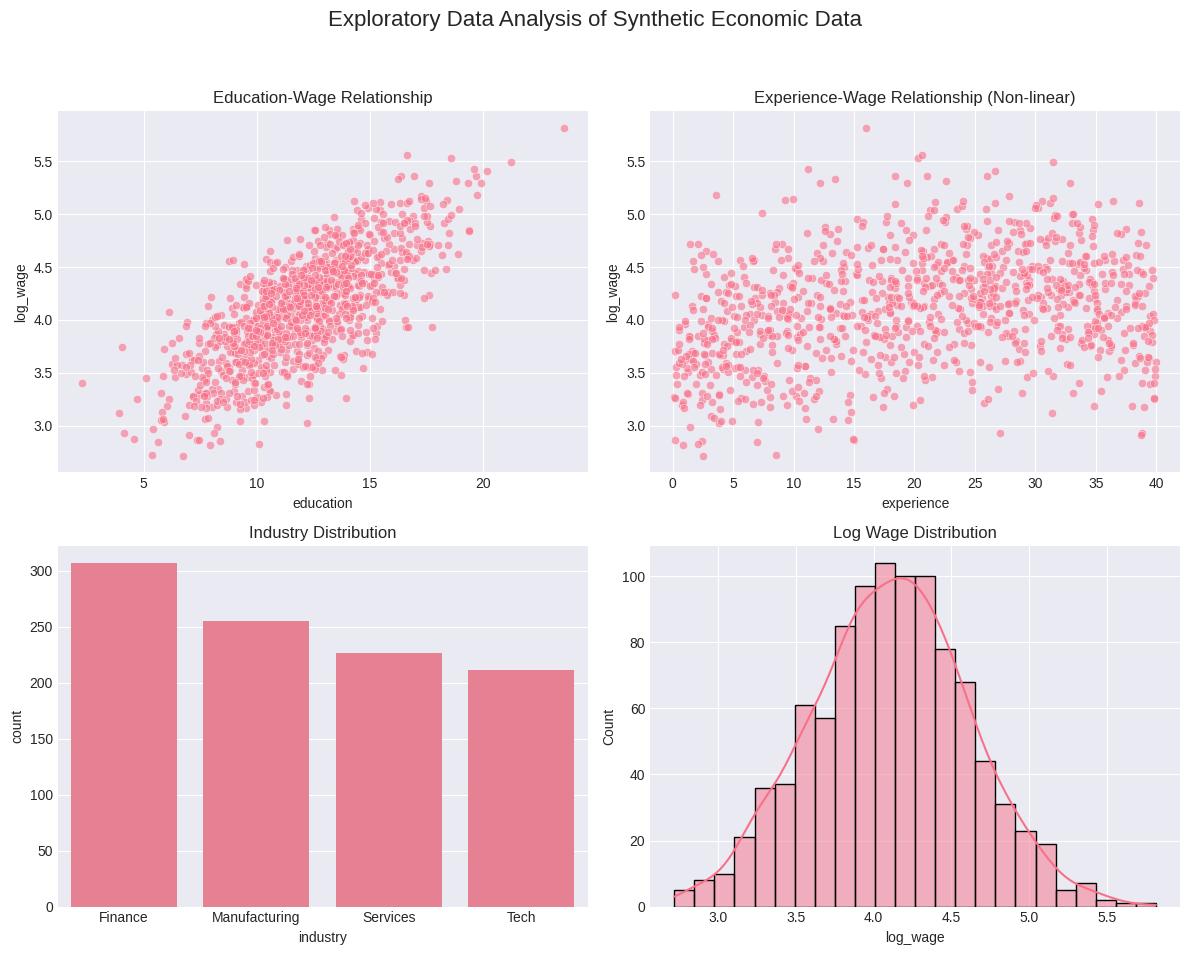

In [ ]:
# Visualize relationships in the synthetic data
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Exploratory Data Analysis of Synthetic Economic Data', fontsize=16)

sns.scatterplot(data=economic_data, x='education', y='log_wage', alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title('Education-Wage Relationship')

sns.scatterplot(data=economic_data, x='experience', y='log_wage', alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title('Experience-Wage Relationship (Non-linear)')

sns.countplot(data=economic_data, x='industry', ax=axes[1, 0], order=economic_data['industry'].value_counts().index)
axes[1, 0].set_title('Industry Distribution')

sns.histplot(data=economic_data, x='log_wage', kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Log Wage Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Create a correlation matrix of the numerical features in the unscaled data
correlation_matrix = X_unscaled.select_dtypes(include=np.number).corr()

# Use Plotly Express to create a heatmap of the correlation matrix
fig = px.imshow(correlation_matrix,
                text_auto=True,
                aspect="auto",
                title='Correlation Matrix of Numerical Features')
fig.show()

## Data Preprocessing Pipeline

Machine learning models require data to be in a clean, numerical format. This preprocessing pipeline will:
1.  **Handle Missing Values**: We'll fill in (impute) missing `ability` data using the mean.
2.  **Encode Categorical Variables**: We'll convert the `industry` column into numerical format using one-hot encoding.
3.  **Feature Scaling**: We'll standardize the features to have a mean of 0 and a standard deviation of 1. This is important for many ML algorithms (like Ridge and Lasso) that are sensitive to the scale of the input features.

In [ ]:
def preprocess_data(df, target_column, scale=True):
    """
    Preprocesses economic data for ML algorithms.
    """
    X = df.drop(columns=[target_column]).copy()
    y = df[target_column].copy()

    # Add experience squared term if not present
    if 'experience' in X.columns and 'experience_squared' not in X.columns:
        X['experience_squared'] = X['experience'] ** 2

    # Impute missing values (mean for numeric)
    numeric_cols_with_na = X.select_dtypes(include=np.number).columns[X.select_dtypes(include=np.number).isnull().any()]
    for col in numeric_cols_with_na:
        imputer = SimpleImputer(strategy='mean')
        X[col] = imputer.fit_transform(X[[col]])

    # One-hot encode categorical variables
    X = pd.get_dummies(X, drop_first=True)
    feature_names = X.columns.tolist()

    # Scale features if required
    if scale:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        X = pd.DataFrame(X_scaled, columns=feature_names)

    return X, y, feature_names

In [ ]:
# Preprocess our economic data
X_scaled,   y_scaled,   feature_names = preprocess_data(economic_data.copy(), target_column='log_wage', scale=True)
X_unscaled, y_unscaled, feature_names = preprocess_data(economic_data.copy(), target_column='log_wage', scale=False)

In [ ]:
print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Target vector shape: {y_scaled.shape}")
print(f"\nFeatures after preprocessing:")
for i, name in enumerate(feature_names):
    print(f"  {i+1}. {name}")

Feature matrix shape: (1000, 7)
Target vector shape: (1000,)

Features after preprocessing:
  1. education
  2. experience
  3. ability
  4. experience_squared
  5. industry_Manufacturing
  6. industry_Services
  7. industry_Tech


In [ ]:
X_unscaled.head()

,education,experience,ability,experience_squared,industry_Manufacturing,industry_Services,industry_Tech
0,13.490142,6.699303,3.608767,44.880665,False,False,False
1,11.585207,4.182714,2.723406,17.495093,False,False,False
2,13.943066,25.457210,4.502094,648.069540,True,False,False
3,16.569090,28.259029,3.608767,798.572723,False,False,True
4,11.297540,1.263446,1.514089,1.596295,False,False,False


In [ ]:
X_scaled.head()

,education,experience,ability,experience_squared,industry_Manufacturing,industry_Services,industry_Tech
0,0.487759,-1.166383,-3.387321e-16,-1.042862,-0.585049,-0.541905,-0.517134
1,-0.161022,-1.384676,-6.753158e-01,-1.100688,-0.585049,-0.541905,-0.517134
2,0.642015,0.460707,6.813912e-01,0.230800,1.709260,-0.541905,-0.517134
3,1.536382,0.703741,-3.387321e-16,0.548594,-0.585049,-0.541905,1.933736
4,-0.258995,-1.637897,-1.597730e+00,-1.134259,-0.585049,-0.541905,-0.517134


In [ ]:
y_unscaled.head()

,log_wage
0,4.564044
1,3.532389
2,4.429801
3,4.927881
4,3.303354


In [ ]:
y_scaled.head()
# NOTE: The y variable is not scaled. Scaling is NOT really needed for the way variable.

,log_wage
0,4.564044
1,3.532389
2,4.429801
3,4.927881
4,3.303354


In [ ]:
feature_names

['education',
 'experience',
 'ability',
 'experience_squared',
 'industry_Manufacturing',
 'industry_Services',
 'industry_Tech']

## Standard Regression Analysis

In [ ]:
full_data_unscaled = X_unscaled.copy()
full_data_unscaled['log_wage'] = y_unscaled
full_data_unscaled

,education,experience,ability,experience_squared,industry_Manufacturing,industry_Services,industry_Tech,log_wage
0,13.490142,6.699303,3.608767,44.880665,False,False,False,4.564044
1,11.585207,4.182714,2.723406,17.495093,False,False,False,3.532389
2,13.943066,25.457210,4.502094,648.069540,True,False,False,4.429801
3,16.569090,28.259029,3.608767,798.572723,False,False,True,4.927881
4,11.297540,1.263446,1.514089,1.596295,False,False,False,3.303354
...,...,...,...,...,...,...,...,...
995,11.156699,11.227329,2.697245,126.052908,False,False,True,4.396545
996,17.393060,8.279703,4.014717,68.553484,False,False,False,4.475805
997,13.922529,20.662905,3.134714,426.955649,False,False,False,4.606522
998,10.286463,0.220232,2.598736,0.048502,True,False,False,3.265585


In [ ]:
m1 = smf.ols(formula='log_wage ~ education', data=full_data_unscaled).fit()
m2 = smf.ols(formula='log_wage ~ education + experience + experience_squared + industry_Manufacturing + industry_Services + industry_Tech', data=full_data_unscaled).fit()
m3 = smf.ols(formula='log_wage ~ education + experience + experience_squared + ability + industry_Manufacturing + industry_Services + industry_Tech', data=full_data_unscaled).fit()

In [ ]:
reg_table = Stargazer([m1, m2, m3])
reg_table

## Train and Test Datasets

A crucial step in machine learning is to evaluate the model on data it has never seen before. This prevents **overfitting**, where a model learns the training data's noise and random fluctuations instead of the underlying signal. We hold back a portion of the data (the test set) for a final, unbiased evaluation of the model's generalization performance.

In [ ]:
# Split the scaled data for predictive modeling
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

In [ ]:
X_train
# NOTE: X_train is scaled

,education,experience,ability,experience_squared,industry_Manufacturing,industry_Services,industry_Tech
29,-0.317786,-0.578576,-0.886693,-0.754176,1.709260,-0.541905,-0.517134
535,0.028677,0.340834,0.619990,0.086262,1.709260,-0.541905,-0.517134
695,-0.336027,-1.196133,1.092282,-1.052317,1.709260,-0.541905,-0.517134
557,-0.461713,1.189627,-0.704867,1.283340,-0.585049,1.845342,-0.517134
836,1.564450,0.194672,1.121641,-0.079064,-0.585049,-0.541905,1.933736
...,...,...,...,...,...,...,...
106,1.907432,-1.620253,0.955287,-1.133086,-0.585049,-0.541905,-0.517134
270,1.452849,0.568681,0.619479,0.367896,-0.585049,-0.541905,-0.517134
860,0.187582,-1.254896,-0.149992,-1.069533,-0.585049,-0.541905,-0.517134
435,0.055953,0.417216,-0.449740,0.177429,1.709260,-0.541905,-0.517134


In [ ]:
y_train
# NOTE: y_train is NOT scaled

,log_wage
29,3.771404
535,3.880758
695,3.725923
557,3.806222
836,4.942031
...,...
106,4.718131
270,5.100360
860,4.132591
435,4.194886


In [ ]:
# Also create unscaled splits for the causal inference section later
X_train_unscaled, X_test_unscaled, y_train_unscaled, y_test_unscaled = train_test_split(
    X_unscaled, y_unscaled, test_size=0.2, random_state=42
)

In [ ]:
print(f"Training set size: {X_train.shape[0]} samples ({100*X_train.shape[0]/X_scaled.shape[0]:.0f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({100*X_test.shape[0]/X_scaled.shape[0]:.0f}%)")

Training set size: 800 samples (80%)
Test set size: 200 samples (20%)


## Causal Inference: Omitted Variable Bias

### 🤔 Check Your Intuition

In our simulated data, `ability` is positively correlated with both `education` and `log_wage`. If we run a simple OLS regression of `log_wage` on `education` but *omit* `ability`, in which direction do you expect the coefficient for `education` to be biased? Upwards (overestimating the return) or downwards (underestimating it)? Why?

In [ ]:
# --- 1. Naive OLS (omitting 'ability') ---
X_naive = X_unscaled.drop(columns=['ability'])
naive_ols = LinearRegression().fit(X_naive, y_unscaled)
naive_education_coef = naive_ols.coef_[X_naive.columns.tolist().index('education')]

In [ ]:
naive_coeffs = pd.Series(naive_ols.coef_, index=X_naive.columns)
naive_coeffs

,0
education,0.127906
experience,0.052873
experience_squared,-0.001045
industry_Manufacturing,-0.279776
industry_Services,-0.238155
industry_Tech,0.025851


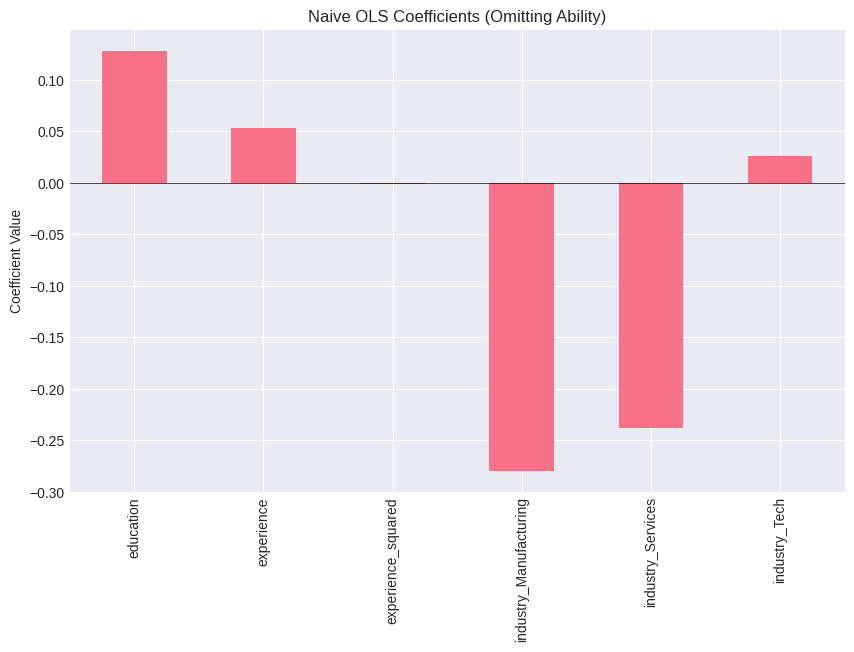

In [ ]:
# Plot the coefficients of the naive_ols model
plt.figure(figsize=(10, 6))
naive_coeffs.plot(kind='bar')
plt.ylabel('Coefficient Value')
plt.title('Naive OLS Coefficients (Omitting Ability)')
plt.axhline(0, color='black', linewidth=0.5)
plt.show()

In [ ]:
# --- 2. Oracle OLS (including the unobserved 'ability') ---
oracle_ols = LinearRegression().fit(X_unscaled, y_unscaled)
oracle_education_coef = oracle_ols.coef_[X_unscaled.columns.tolist().index('education')]

In [ ]:
oracle_coeffs = pd.Series(oracle_ols.coef_, index=X_unscaled.columns)
oracle_coeffs

,0
education,0.084399
experience,0.052468
ability,0.142949
experience_squared,-0.001047
industry_Manufacturing,-0.279686
industry_Services,-0.248754
industry_Tech,0.038086


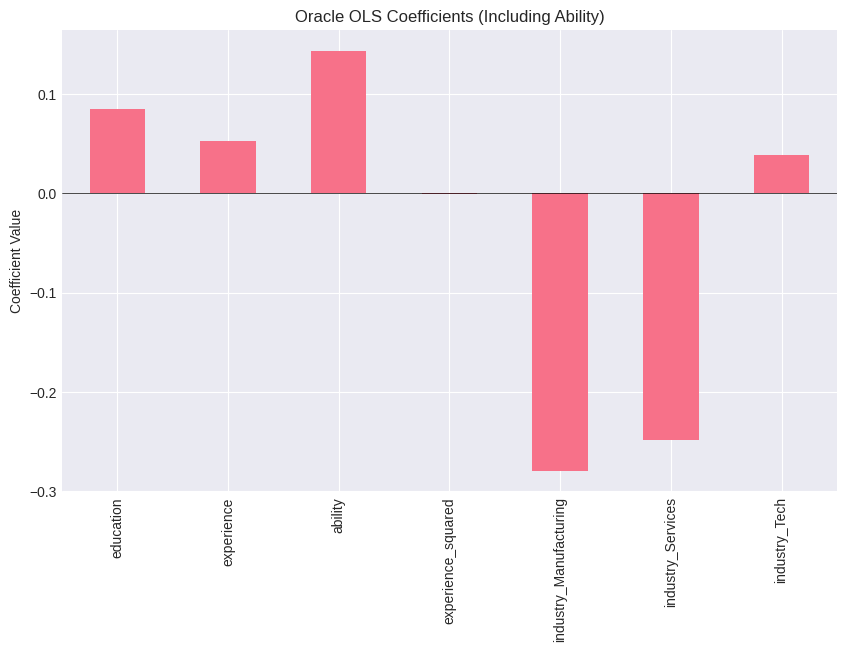

In [ ]:
# Plot the coefficients of the oracle_ols model
plt.figure(figsize=(10, 6))
oracle_coeffs.plot(kind='bar')
plt.ylabel('Coefficient Value')
plt.title('Oracle OLS Coefficients (Including Ability)')
plt.axhline(0, color='black', linewidth=0.5)
plt.show()

In [ ]:
# --- 3. Double/Debiased Machine Learning (DML) ---
Y_dml = full_data_unscaled['log_wage'].dropna().values
T_dml = full_data_unscaled['education'].loc[full_data_unscaled['log_wage'].notna()].values
W_df  = full_data_unscaled.loc[full_data_unscaled['log_wage'].notna()].drop(columns=['log_wage', 'education', 'ability'])
W_dml = pd.get_dummies(W_df, drop_first=True).values

In [ ]:
# Display W_dml as a DataFrame
# W_dml contains the features used in the DML model (excluding education and ability)
# The columns are 'experience', 'experience_squared', and the one-hot encoded industry columns.
# We can get the column names from the one-hot encoded W_df
W_dml_df = pd.DataFrame(W_dml, columns=pd.get_dummies(full_data_unscaled.loc[full_data_unscaled['log_wage'].notna()].drop(columns=['log_wage', 'education', 'ability']), drop_first=True).columns)
display(W_dml_df.head())

,experience,experience_squared,industry_Manufacturing,industry_Services,industry_Tech
0,6.699303,44.880665,False,False,False
1,4.182714,17.495093,False,False,False
2,25.45721,648.06954,True,False,False
3,28.259029,798.572723,False,False,True
4,1.263446,1.596295,False,False,False


In [ ]:
# Pass W_dml as the X argument
dml_est = CausalForestDML(random_state=42).fit(Y_dml, T_dml, X=W_dml)
dml_education_coef = dml_est.effect(X=W_dml).mean() # Calculate mean effect over the data used for fitting
dml_ci_lower, dml_ci_upper = dml_est.effect_interval(X=W_dml, alpha=0.05) # Get lower and upper bounds
dml_ci_mean = (dml_ci_lower.mean(), dml_ci_upper.mean()) # Calculate mean of lower and upper bounds

In [ ]:
# --- Display Results ---
summary_df = pd.DataFrame({
    'Method': ['True Parameter', 'Naive OLS', 'Oracle OLS', 'Double ML'],
    'Return to Education': [0.080, naive_education_coef, oracle_education_coef, dml_education_coef],
    '95% CI': [None, None, None, f"[{dml_ci_mean[0]:.3f}, {dml_ci_mean[1]:.3f}]"]
}).set_index('Method')

In [ ]:
print("--- Causal Estimates for Return to Education ---")
display(summary_df.round(4))

--- Causal Estimates for Return to Education ---


,Return to Education,95% CI
Method,,
True Parameter,0.0800,None
Naive OLS,0.1279,None
Oracle OLS,0.0844,None
Double ML,0.1291,"[0.107, 0.151]"


## Understanding Regularization

Regularization (like in Ridge regression) adds a penalty to the size of the coefficients. The strength of this penalty is controlled by a **hyperparameter** called `alpha`. Let's visualize how the coefficients of our model change as we adjust `alpha`.

**Instructions:** Move the slider below. A high `alpha` imposes a strong penalty, shrinking the coefficients towards zero. A low `alpha` is similar to a standard OLS model.

In [ ]:
# This widget allows you to interactively see the effect of the alpha parameter.
# NOTE:  X_train is scaled, but y_train is NOT scales
def plot_ridge_coeffs(alpha):
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)

    coeffs = pd.Series(ridge.coef_, index=feature_names)

    plt.figure(figsize=(10, 6))
    coeffs.plot(kind='bar')
    plt.ylim(-0.52, 0.62) # Set fixed y-axis limits
    plt.title(f'Ridge Coefficients with alpha = {alpha:.3f}')
    plt.ylabel('Coefficient Value')
    plt.axhline(0, color='black', linewidth=0.5)
    plt.show()

interact(plot_ridge_coeffs, alpha=FloatSlider(min=0.001, max=50.0, step=0.1, value=0.001, description='Alpha'));

interactive(children=(FloatSlider(value=0.001, description='Alpha', max=50.0, min=0.001), Output()), _dom_clas…

In [ ]:
# This widget allows you to interactively see the effect of the alpha parameter.
def plot_lasso_coeffs(alpha):
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)

    coeffs = pd.Series(lasso.coef_, index=feature_names)

    plt.figure(figsize=(10, 6))
    coeffs.plot(kind='bar')
    plt.title(f'Lasso Coefficients with alpha = {alpha:.3f}')
    plt.ylabel('Coefficient Value')
    plt.ylim(-0.5, 0.6) # Set fixed y-axis limits
    plt.axhline(0, color='black', linewidth=0.5)
    plt.show()

interact(plot_lasso_coeffs, alpha=FloatSlider(min=0.001, max=0.35, step=0.001, value=0.001, description='Alpha'));

interactive(children=(FloatSlider(value=0.001, description='Alpha', max=0.35, min=0.001, step=0.001), Output()…

## Tree-Based Models & Hyperparameter Tuning

### 🤔 Check Your Intuition
Our EDA showed a non-linear relationship between `experience` and `log_wage`. Do you expect a tree-based model like a Random Forest to perform better or worse than a linear model (like Ridge) at predicting wages? Why?

In [ ]:
# --- Simple Tree-Based Models ---
print("--- Evaluating Basic Tree-Based Models ---")
tree_models = {
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
}
for name, model in tree_models.items():
    model.fit(X_train, y_train)
    print(f"{name:>15} | Test R²: {r2_score(y_test, model.predict(X_test)):.4f}")

# --- Hyperparameter Tuning for Random Forest ---
print("\n--- Tuning Random Forest Hyperparameters ---")
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
rf = RandomForestRegressor(random_state=42)
rand_search = RandomizedSearchCV(rf, param_dist, n_iter=5, cv=3, scoring='r2', random_state=42)
rand_search.fit(X_train, y_train)
best_rf = rand_search.best_estimator_

print(f"   Best parameters found: {rand_search.best_params_}")
print(f"   Test R² of tuned RF model: {r2_score(y_test, best_rf.predict(X_test)):.4f}")

--- Evaluating Basic Tree-Based Models ---
  Decision Tree | Test R²: 0.6816
  Random Forest | Test R²: 0.7748

--- Tuning Random Forest Hyperparameters ---
   Best parameters found: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10}
   Test R² of tuned RF model: 0.7746


## Comparative Model Evaluation

In [ ]:
# Define the models to be evaluated
models = {
    'OLS': LinearRegression(),
    'Lasso': Lasso(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}


In [ ]:
# Hyperparameter tuning (using RandomizedSearchCV for efficiency)

# Define parameter distributions for RandomizedSearchCV
param_dist_lasso = {
    'alpha': np.logspace(-4, 2, 10)
}

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

param_dist_gbm = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

tuned_models = {}
for name, model in models.items():
    if name == 'OLS':
        tuned_models[name] = model # OLS has no hyperparameters to tune
        print(f"Skipping tuning for {name}. No hyperparameters to tune for OLS.")
        continue

    print(f"Tuning {name}...")
    if name == 'Lasso':
        param_dist = param_dist_lasso
        n_iter = 10 # Use all combinations for Lasso
    elif name == 'Random Forest':
        param_dist = param_dist_rf
        n_iter = 10 # Reduced iterations for faster tuning
    elif name == 'Gradient Boosting':
        param_dist = param_dist_gbm
        n_iter = 10 # Reduced iterations for faster tuning

    rand_search = RandomizedSearchCV(model, param_dist, n_iter=n_iter, cv=5, scoring='r2', random_state=42)
    rand_search.fit(X_train, y_train)
    tuned_models[name] = rand_search.best_estimator_
    print(f"   Best parameters for {name}: {rand_search.best_params_}")


Skipping tuning for OLS. No hyperparameters to tune for OLS.
Tuning Lasso...
   Best parameters for Lasso: {'alpha': np.float64(0.0001)}
Tuning Random Forest...
   Best parameters for Random Forest: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 15}
Tuning Gradient Boosting...
   Best parameters for Gradient Boosting: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.1}


In [ ]:
# Single train-test evaluation
performance_test = pd.DataFrame(columns=['Model', 'R-squared', 'MSE'])
for name, model in tuned_models.items():
    if name == 'OLS':
        model.fit(X_train, y_train) # Fit OLS model before predicting
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    performance_test = pd.concat([performance_test, pd.DataFrame([{'Model': name, 'R-squared': r2, 'MSE': mse}])], ignore_index=True)

print("Performance on Test Set:")
display(performance_test)

Performance on Test Set:


,Model,R-squared,MSE
0,OLS,0.854336,0.038733
1,Lasso,0.854273,0.038750
2,Random Forest,0.777480,0.059169
3,Gradient Boosting,0.812770,0.049785


In [ ]:
fig = px.bar(performance_test, x='Model', y='R-squared',
             title='R-squared on Test Set')
fig.show()

In [ ]:
# Cross-Validation Evaluation (5-fold)
performance_cv = pd.DataFrame(columns=['Model', 'Mean R-squared', 'Std Dev R-squared'])
for name, model in tuned_models.items():
    # Use the full dataset for cross-validation to get a robust estimate
    cv_scores = cross_val_score(model, X_scaled, y_scaled, cv=5, scoring='r2')
    mean_r2 = np.mean(cv_scores)
    std_r2 = np.std(cv_scores)
    performance_cv = pd.concat([performance_cv, pd.DataFrame([{'Model': name, 'Mean R-squared': mean_r2, 'Std Dev R-squared': std_r2}])], ignore_index=True)

print("Cross-Validation Performance:")
display(performance_cv)

Cross-Validation Performance:


,Model,Mean R-squared,Std Dev R-squared
0,OLS,0.836235,0.013085
1,Lasso,0.836236,0.013060
2,Random Forest,0.778567,0.022742
3,Gradient Boosting,0.813844,0.016121


In [ ]:
fig = px.bar(performance_cv, x='Model', y='Mean R-squared',
             title='Mean R-squared (Cross-Validation)')
fig.show()

## Model Interpretation with SHAP

**SHAP (SHapley Additive exPlanations)** is a powerful method to explain individual predictions. It shows how each feature contributes to pushing a prediction away from the baseline (the average prediction).

In [ ]:
# Explain the predictions of our best Random Forest model
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

### Local Interpretability
Local plots explain *why* a single prediction was made. This is incredibly powerful for understanding model behavior for a specific individual or scenario.

In [ ]:
# Find the index of the observation with the median predicted log wage
median_y_pred_index = np.argsort(best_rf.predict(X_test))[len(X_test)//2]
median_y_pred_index

np.int64(173)


--- SHAP Waterfall Plot for Observation with Median Predicted Log Wage ---


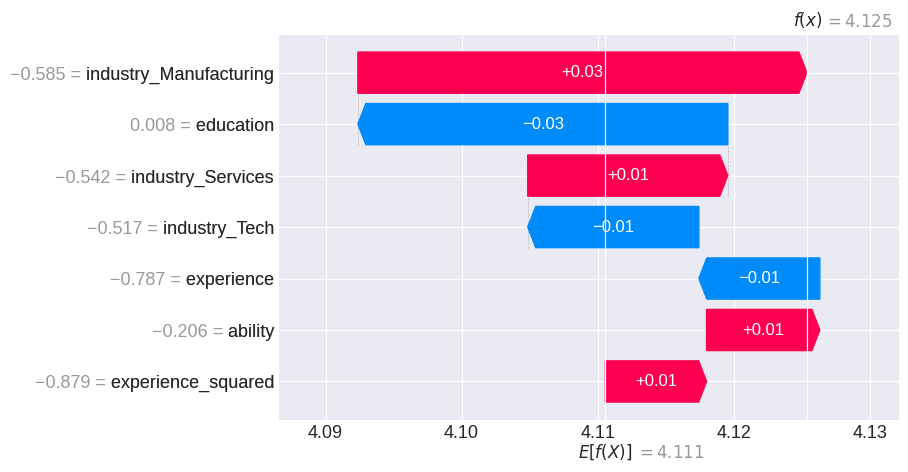

In [ ]:
print("\n--- SHAP Waterfall Plot for Observation with Median Predicted Log Wage ---")

# Explain the prediction for the observation with the median predicted log wage
shap.waterfall_plot(shap.Explanation(values=shap_values[median_y_pred_index],
                                     base_values=explainer.expected_value,
                                     data=X_test.iloc[median_y_pred_index,:],
                                     feature_names=feature_names))

In [ ]:
print("\n--- SHAP Force Plot for Observation with Median Predicted Log Wage ---")
# Initialize javascript for visualization in the notebook
shap.initjs()

# Explain the prediction for the observation with the median predicted log wage
shap.force_plot(explainer.expected_value, shap_values[median_y_pred_index], X_test.iloc[median_y_pred_index,:], feature_names=feature_names)


--- SHAP Force Plot for Observation with Median Predicted Log Wage ---


**How to Read the Force Plot:**
* **Base Value:** The average predicted log wage across all individuals (`explainer.expected_value`).
* **Red Bars:** Features pushing the prediction **higher** than the base value (e.g., high `education` and `ability`).
* **Blue Bars:** Features pushing the prediction **lower** (e.g., low `experience`).
* **Final Prediction:** The bold number is the final predicted log wage for this individual, which is the sum of the base value and all feature contributions.

### Global Interpretability
These plots summarize the model's behavior across the entire dataset.

--- SHAP Global Feature Importance (Bar Plot) ---


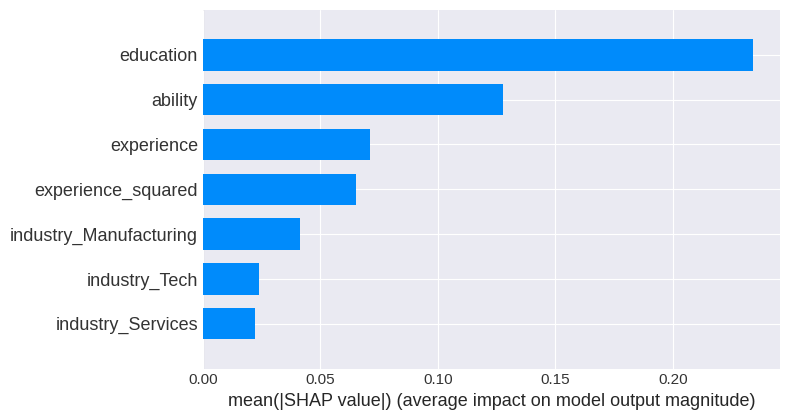

In [ ]:
print("--- SHAP Global Feature Importance (Bar Plot) ---")
shap.summary_plot(shap_values, X_test, feature_names=feature_names, plot_type="bar")


--- SHAP Summary Plot (Beeswarm) ---


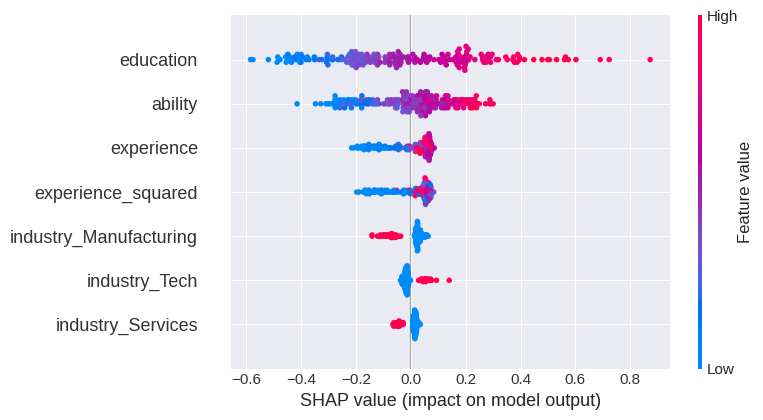

In [ ]:
print("\n--- SHAP Summary Plot (Beeswarm) ---")
shap.summary_plot(shap_values, X_test, feature_names=feature_names)

**How to Read the Beeswarm Plot:**
* **Feature Importance:** Variables are ranked by importance on the y-axis.
* **Impact:** The x-axis shows the SHAP value. Positive values mean the feature pushed the prediction higher (higher wage), negative values pushed it lower.
* **Original Value:** Color indicates the original value of the feature (red = high, blue = low).

**Insight:** We can see not just *that* `education` is important, but *how*. High values of education (red dots) have high positive SHAP values, increasing the predicted log wage, as economic theory would suggest.

## Classification Models

Many economic problems are about classification rather than regression (e.g., predicting loan default, recession, or labor force participation). We can convert our regression problem into a classification task: predicting if a person is a **high earner** (log wage above the median).

For this, we'll use **Logistic Regression** (analogous to Logit/Probit models) and a **Random Forest Classifier**. We'll evaluate them using the **Area Under the ROC Curve (AUC)**, a robust metric for classification performance.

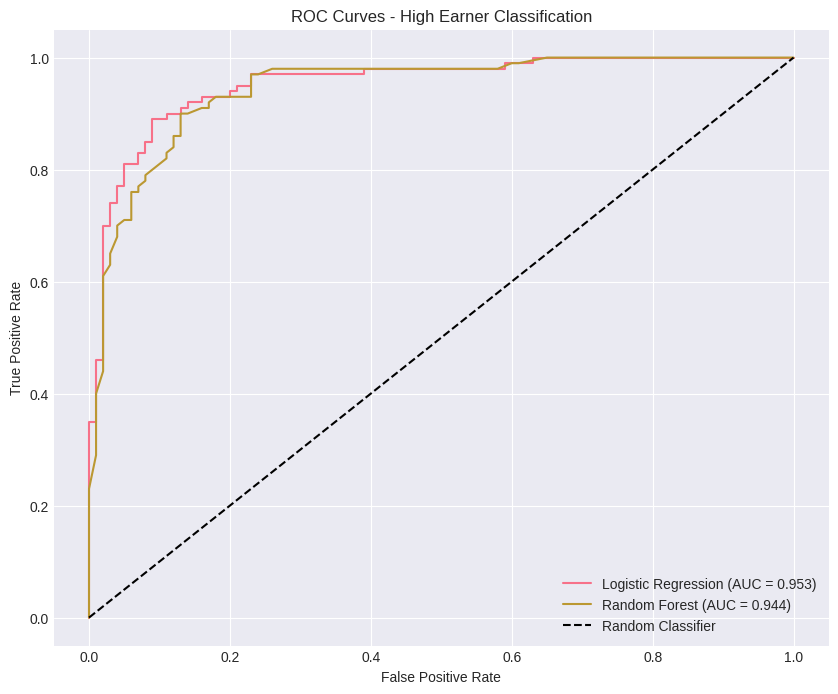

In [ ]:
# Create a binary target variable
classification_data = economic_data.copy()
median_wage = classification_data['log_wage'].median()
classification_data['high_earner'] = (classification_data['log_wage'] > median_wage).astype(int)

# Preprocess for classification
X_c, y_c, _ = preprocess_data(classification_data.drop(columns=['log_wage']), 'high_earner')
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42, stratify=y_c)

# --- Evaluate Classifiers ---
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

fig, ax = plt.subplots(figsize=(10, 8))
for name, model in classifiers.items():
    model.fit(X_train_c, y_train_c)
    y_pred_proba = model.predict_proba(X_test_c)[:, 1]
    auc = roc_auc_score(y_test_c, y_pred_proba)
    fpr, tpr, _ = roc_curve(y_test_c, y_pred_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

# Finalize ROC plot
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - High Earner Classification')
ax.legend()
plt.show()

**Your Turn: Mini-Exercise**

Now, it's your turn to practice! Let's create a different binary classification problem.

**Task:** Create a new target variable called `is_finance` that is `1` if the `industry` is 'Finance' and `0` otherwise. Then, fit a Logistic Regression model to predict this new target. Report its accuracy on the test set.

This cell has the solution filled in so you can run it and see a working example.

In [ ]:
# Create the new target variable
exercise_data = economic_data.copy().dropna()
exercise_data['is_finance'] = (exercise_data['industry'] == 'Finance').astype(int)

# Preprocess the data for this new target
X_ex, y_ex, _ = preprocess_data(exercise_data.drop(columns=['log_wage', 'industry']),
                                target_column='is_finance')

# Split the data
X_train_ex, X_test_ex, y_train_ex, y_test_ex = train_test_split(
    X_ex, y_ex, test_size=0.2, random_state=42, stratify=y_ex
)

# Initialize and fit the Logistic Regression model
log_reg_ex = LogisticRegression(random_state=42)
log_reg_ex.fit(X_train_ex, y_train_ex)

# Make predictions and calculate accuracy
y_pred_ex = log_reg_ex.predict(X_test_ex)
accuracy = accuracy_score(y_test_ex, y_pred_ex)

print(f"The accuracy of the Logistic Regression model in predicting the 'is_finance' class is: {accuracy:.2%}")

The accuracy of the Logistic Regression model in predicting the 'is_finance' class is: 69.47%


## Unsupervised Learning: Discovering Patterns

**Unsupervised learning** finds patterns in data without a labeled target variable. We'll use two common techniques:

* **Principal Component Analysis (PCA):** A dimensionality reduction technique that transforms features into a smaller set of uncorrelated variables called principal components. It helps visualize high-dimensional data.
* **K-Means Clustering:** An algorithm that partitions data into *K* distinct, non-overlapping clusters based on feature similarity.

Explained variance by PC1: 28.34%
Explained variance by PC2: 23.82%


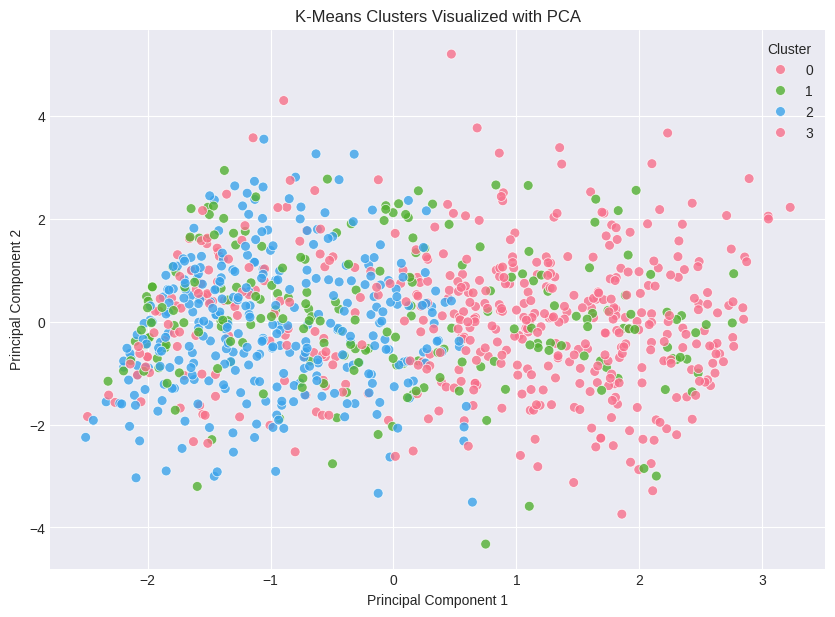

In [ ]:
# --- Principal Component Analysis (PCA) ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled) # Use the scaled data
print(f"Explained variance by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Explained variance by PC2: {pca.explained_variance_ratio_[1]:.2%}")

# --- K-Means Clustering ---
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Visualize clusters on the first two principal components
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='husl', alpha=0.8, s=50)
plt.title('K-Means Clusters Visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

## Model Diagnostics: Residual Analysis 🩺

A standard practice in econometrics is to analyze the residuals (the prediction errors) of a model to check for violations of assumptions. This is just as important in machine learning.

A well-behaved model should have residuals that are randomly scattered around zero, with no discernible pattern. Let's check this for our best-tuned predictive model, the Ridge regression.

In [ ]:
# --- Hyperparameter Tuning for Ridge Regression ---
print("--- Tuning Ridge Regression Hyperparameters ---")
param_grid_ridge = {
    'alpha': np.logspace(-4, 2, 10) # Alpha values from 0.0001 to 100
}
ridge = Ridge(random_state=42)
grid_search = GridSearchCV(ridge, param_grid_ridge, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)
best_ridge_model = grid_search.best_estimator_

print(f"   Best parameters found: {grid_search.best_params_}")
print(f"   Test R² of tuned Ridge model: {r2_score(y_test, best_ridge_model.predict(X_test)):.4f}")

--- Tuning Ridge Regression Hyperparameters ---
   Best parameters found: {'alpha': np.float64(0.01)}
   Test R² of tuned Ridge model: 0.8543


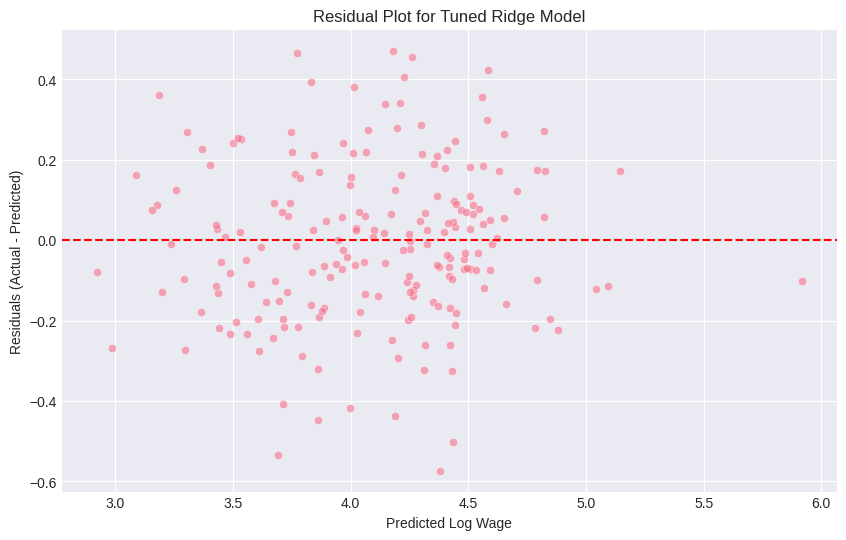

In [ ]:
# Get the best tuned Ridge model from our earlier grid search
best_ridge_model = grid_search.best_estimator_

# Calculate predictions and residuals on the test set
y_pred_ridge = best_ridge_model.predict(X_test)
residuals = y_test - y_pred_ridge

# Plot residuals vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_ridge, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Log Wage')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot for Tuned Ridge Model')
plt.show()

**Insight:** The residuals appear to be randomly scattered around the zero line, with no obvious patterns (like a cone shape, which would suggest heteroskedasticity). This gives us more confidence in our model's performance.

## Conclusions

Machine learning does not replace econometrics; it **complements** it. ML provides a powerful toolkit for prediction, pattern discovery, and handling high-dimensional data, while econometrics remains the gold standard for causal inference and hypothesis testing.